In [124]:
import tensorflow
import numpy as np 
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons , make_circles
import seaborn as sns




In [125]:
X,y = make_circles(n_samples=100,noise=.1,random_state=1)
X[:,0]

array([-0.63640493, -0.24465976, -0.46597138, -0.70999784,  0.70232238,
       -0.49776571, -0.31914906, -0.57839322, -0.53350227, -0.24733259,
        0.41030774,  0.17181003,  0.65917045,  0.87625577,  0.81946243,
       -0.47960986, -0.90187751,  0.74827659, -0.74875324,  0.23161178,
        0.81387506, -0.92169575,  0.74650434,  0.01330079, -0.72651409,
       -0.33930852,  0.49009938, -0.9539309 ,  0.6927241 ,  0.003546  ,
       -0.35077763,  0.94798269,  0.52327611,  0.54670705,  0.10385825,
        0.31843503,  0.92901189,  0.20498887, -1.01797423, -0.51324637,
       -0.12292134,  0.71008749, -0.71742651, -0.13663998, -0.57877973,
        0.41812614,  0.84575703,  0.26707772, -0.87474347,  0.62430557,
        0.65495356,  0.57445296, -1.0617065 ,  0.96779554,  0.49980305,
        0.9717675 , -0.74061828,  0.08203902,  0.9202249 , -0.77079544,
       -0.8114891 , -0.3501353 , -0.74376426,  0.63771423,  0.75136154,
        0.22716539,  0.52855241,  0.33982534,  1.02669518,  0.17

<Axes: >

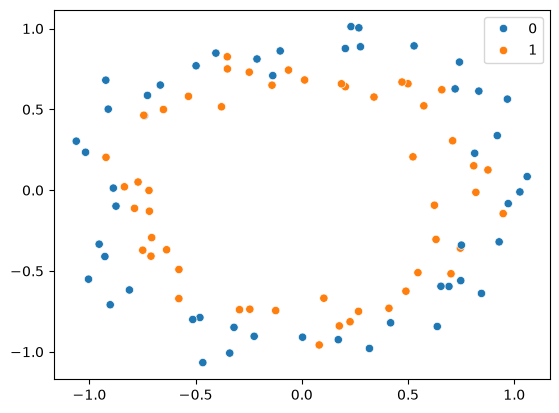

In [126]:
#plt.scatter(x=X[:,0],y = X[:,1],c=y)
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [127]:
X_train ,X_test , Y_train , Y_test = train_test_split(X,y ,test_size=.20,random_state=2)

In [128]:
model = Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/Users/All file hear/complete ai /Deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [129]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [130]:
history = model.fit(X_train , Y_train,validation_data=(X_test,Y_test),epochs=3500,verbose=0)

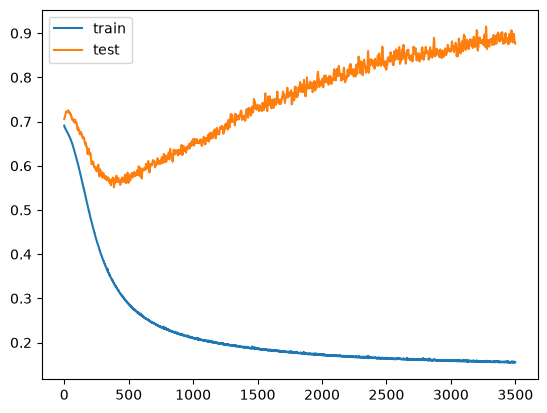

In [131]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [132]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

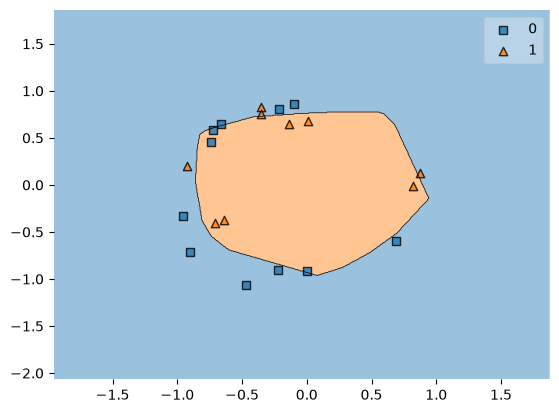

In [133]:
class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        predictions = self.model.predict(X, verbose=0)
        return (predictions > 0.5).astype(int).ravel()

clf = ModelWrapper(model)

plot_decision_regions(X_test, Y_test.ravel(), clf=clf)

# Early Stopping

In [134]:
model2 = Sequential()
model2.add(Dense(256,activation='relu',input_dim=2))
model2.add(Dense(1,activation='sigmoid'))

In [135]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [136]:
call_back = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [146]:
history1 = model2.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=3500,callbacks=call_back)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5875 - loss: 0.6756 - val_accuracy: 0.4500 - val_loss: 0.7170
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5625 - loss: 0.6751 - val_accuracy: 0.4500 - val_loss: 0.7175
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5750 - loss: 0.6744 - val_accuracy: 0.4500 - val_loss: 0.7180
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5750 - loss: 0.6740 - val_accuracy: 0.4500 - val_loss: 0.7187
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5875 - loss: 0.6734 - val_accuracy: 0.4500 - val_loss: 0.7194
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5750 - loss: 0.6729 - val_accuracy: 0.4500 - val_loss: 0.7200
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5750 - loss: 0.6722 - val_accuracy: 0.4500 - val_loss: 0.7205
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5625 - loss: 0.6717 - val_accuracy: 0.4500 - val_loss: 0.72

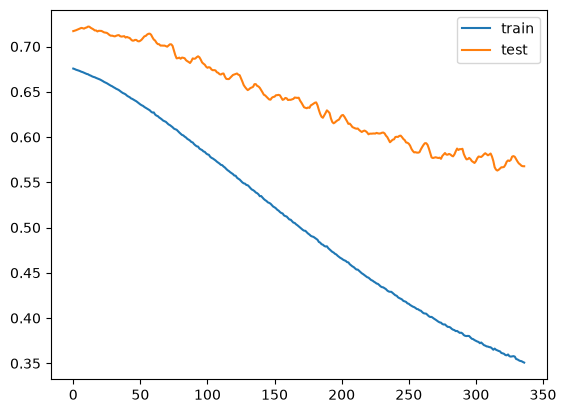

In [147]:
plt.plot(history1.history['loss'],label='train')
plt.plot(history1.history['val_loss'],label='test')
plt.legend()
plt.show()

In [148]:
print(Y_test.dtype)
X_test.dtype

int64


dtype('float64')

In [149]:
print(np.isnan(X_test).sum())
print(np.isinf(X_test).sum())

print(X_test.shape)
print(type(model2))

0
0
(20, 2)
<class 'keras.src.models.sequential.Sequential'>


<Axes: >

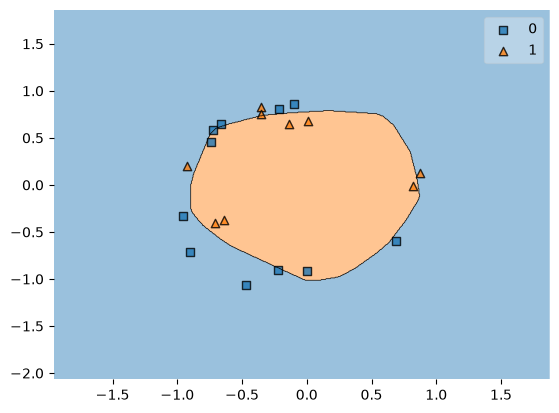

In [154]:
class ModelWrapper:
    def __init__(self, model2):
        self.model2 = model2

    def predict(self, X):
        predictions = self.model2.predict(X, verbose=0)
        return (predictions > 0.5).astype(int).ravel()

clf = ModelWrapper(model2)

plot_decision_regions(X_test, Y_test.ravel(), clf=clf)